In [102]:
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

In [3]:
df1= pd.read_csv(r"C:/Users/zahra/Downloads/movie_project//dataset/name.basics.tsv/name.basics.tsv", sep="\t", na_values=['\\NA'])

In [4]:
df2= pd.read_csv(r"C:/Users/zahra/Downloads/movie_project/dataset/title.basics.tsv/title.basics.tsv", sep= "\t", na_values= ['\\NA'])

In [5]:
df2= df2.drop(index= df2[df2['titleType'] != 'movie'].index)

In [6]:
df3= pd.read_csv(r"C:/Users/zahra/Downloads/movie_project/dataset/title.crew.tsv/title.crew.tsv", sep="\t", na_values= ['\\NA'])

In [7]:
df3= df3.drop_duplicates(df3[['tconst']])

In [8]:
df4= pd.read_csv(r"C:/Users/zahra/Downloads/movie_project/dataset/title.principals.tsv/title.principals.tsv", sep="\t", na_values= ['\\NA'])

In [9]:
df4= df4.drop_duplicates(df4[['tconst']])

In [10]:
df5= pd.read_csv(r"C:/Users/zahra/Downloads/movie_project/dataset/title.ratings.tsv/title.ratings.tsv", sep= "\t", na_values=['\\NA'])

In [11]:
df5= df5.drop_duplicates(df5[['tconst']])

In [12]:
print(df5.columns.tolist())

['tconst', 'averageRating', 'numVotes']


In [13]:
df1_merged= df2.merge(df3, on='tconst', how='left')

In [14]:
df1_merged

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,directors,writers
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,nm0085156,nm0085156
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",nm0714557,\N
2,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,nm0063413,"nm0063413,nm0657268,nm0675388"
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography",nm0846879,nm0846879
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama,nm0141150,nm0141150
...,...,...,...,...,...,...,...,...,...,...,...
741033,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015,\N,57,Documentary,"nm9272490,nm9272491","nm9272490,nm9272491"
741034,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007,\N,100,Documentary,nm0652213,"nm0652213,nm10538576"
741035,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013,\N,\N,Comedy,nm7764440,nm7933903
741036,tt9916730,movie,6 Gunn,6 Gunn,0,2017,\N,116,Drama,nm10538612,nm10538612


In [15]:
df2_merged= df1_merged.merge(df4, on= 'tconst', how='left')

In [16]:
df2_merged

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,directors,writers,ordering,nconst,category,job,characters
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,nm0085156,nm0085156,1.0,nm0063086,actress,\N,"[""Miss Geraldine Holbrook (Miss Jerry)""]"
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",nm0714557,\N,1.0,nm0179163,self,\N,"[""Self""]"
2,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,nm0063413,"nm0063413,nm0657268,nm0675388",1.0,nm0215752,actor,\N,\N
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography",nm0846879,nm0846879,1.0,nm0846887,actress,\N,"[""Kate Kelly""]"
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama,nm0141150,nm0141150,1.0,nm0906197,actor,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741033,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015,\N,57,Documentary,"nm9272490,nm9272491","nm9272490,nm9272491",1.0,nm9272513,actor,\N,"[""Rodolpho Teophilo""]"
741034,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007,\N,100,Documentary,nm0652213,"nm0652213,nm10538576",1.0,nm0033355,self,\N,"[""Self""]"
741035,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013,\N,\N,Comedy,nm7764440,nm7933903,1.0,nm1778107,actor,\N,\N
741036,tt9916730,movie,6 Gunn,6 Gunn,0,2017,\N,116,Drama,nm10538612,nm10538612,1.0,nm6096005,actor,\N,\N


In [17]:
df3_merged= df2_merged.merge(df5, on='tconst', how='left')

In [18]:
df3_merged

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,directors,writers,ordering,nconst,category,job,characters,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,nm0085156,nm0085156,1.0,nm0063086,actress,\N,"[""Miss Geraldine Holbrook (Miss Jerry)""]",5.3,235.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",nm0714557,\N,1.0,nm0179163,self,\N,"[""Self""]",5.3,597.0
2,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,nm0063413,"nm0063413,nm0657268,nm0675388",1.0,nm0215752,actor,\N,\N,3.5,26.0
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography",nm0846879,nm0846879,1.0,nm0846887,actress,\N,"[""Kate Kelly""]",6.0,1065.0
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama,nm0141150,nm0141150,1.0,nm0906197,actor,\N,\N,5.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741033,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015,\N,57,Documentary,"nm9272490,nm9272491","nm9272490,nm9272491",1.0,nm9272513,actor,\N,"[""Rodolpho Teophilo""]",NaN,NaN
741034,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007,\N,100,Documentary,nm0652213,"nm0652213,nm10538576",1.0,nm0033355,self,\N,"[""Self""]",NaN,NaN
741035,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013,\N,\N,Comedy,nm7764440,nm7933903,1.0,nm1778107,actor,\N,\N,7.7,9.0
741036,tt9916730,movie,6 Gunn,6 Gunn,0,2017,\N,116,Drama,nm10538612,nm10538612,1.0,nm6096005,actor,\N,\N,7.0,14.0


In [19]:
df4_merged= df3_merged.merge(df1, on='nconst', how='left')

In [20]:
df4_merged

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,directors,...,category,job,characters,averageRating,numVotes,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,nm0085156,...,actress,\N,"[""Miss Geraldine Holbrook (Miss Jerry)""]",5.3,235.0,Blanche Bayliss,1878,1951,actress,tt0000009
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",nm0714557,...,self,\N,"[""Self""]",5.3,597.0,James J. Corbett,1866,1933,"actor,writer,archive_footage","tt0003116,tt0003730,tt0034778,tt0020949"
2,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,nm0063413,...,actor,\N,\N,3.5,26.0,Antonio del Pozo,\N,\N,actor,tt0000502
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography",nm0846879,...,actress,\N,"[""Kate Kelly""]",6.0,1065.0,Elizabeth Tait,1879,\N,"actress,archive_footage",tt0000574
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama,nm0141150,...,actor,\N,\N,5.0,39.0,Georges Wague,1874,1965,actor,"tt0434033,tt0007518,tt0764742,tt0432622"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741033,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015,\N,57,Documentary,"nm9272490,nm9272491",...,actor,\N,"[""Rodolpho Teophilo""]",NaN,NaN,Oldair Soares Ammom,\N,\N,"actor,writer","tt1095216,tt38581053,tt7373344,tt37242971"
741034,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007,\N,100,Documentary,nm0652213,...,self,\N,"[""Self""]",NaN,NaN,Ramiro Arbeláez,\N,\N,actor,"tt0225033,tt4937126,tt9916680"
741035,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013,\N,\N,Comedy,nm7764440,...,actor,\N,\N,7.7,9.0,Makarand Anaspure,1973,\N,"actor,director,producer","tt5344452,tt0220832,tt0476878,tt2256667"
741036,tt9916730,movie,6 Gunn,6 Gunn,0,2017,\N,116,Drama,nm10538612,...,actor,\N,\N,7.0,14.0,Devadhar Archit,\N,\N,actor,"tt3341582,tt9916730,tt4292228"


In [21]:
df= df4_merged.copy()

In [22]:
df= df.drop(['isAdult', 'titleType', 'originalTitle', 'primaryTitle', 'endYear', 'characters', 'primaryName', 'birthYear', 'deathYear', 'ordering', 'job'], axis= 1)

In [23]:
df= df.dropna(subset= ['knownForTitles', 'primaryProfession'])

In [24]:
df['averageRating']= pd.to_numeric(df['averageRating'], downcast='float', errors= 'coerce')

In [25]:
df['numVotes']= pd.to_numeric(df['numVotes'], downcast='float', errors= 'coerce')

In [26]:
df['startYear']= pd.to_numeric(df['startYear'], downcast= 'float', errors= 'coerce')

In [27]:
df['runtimeMinutes']= pd.to_numeric(df['runtimeMinutes'], downcast='float', errors='coerce')

In [28]:
df['averageRating']= df['averageRating'].fillna(df['averageRating'].median())

In [29]:
print(df['averageRating'].median())

6.300000190734863


In [30]:
df['numVotes']= df['numVotes'].fillna(df['numVotes'].median())

In [31]:
df['startYear']= df['startYear'].fillna(0)

In [32]:
df['runtimMinutes']= df['runtimeMinutes'].fillna(df['runtimeMinutes'].median())

In [33]:
df['genres'].shape

(721551,)

In [34]:
def genre_transforming(df):
    df['genres']= df['genres'].fillna('')
    df['genres']= df['genres'].str.split(',')

    mlb= MultiLabelBinarizer()
    genre_encoded= mlb.fit_transform(df['genres'])
    genre_df= pd.DataFrame(genre_encoded, columns= mlb.classes_)
    return genre_df

In [35]:
genre_df= genre_transforming(df)

In [36]:
df= pd.concat([df, genre_df])

In [37]:
genre_df= genre_df.fillna(0)


In [38]:
genre_df

,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,...,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,\N
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721546,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
721547,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
721548,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
721549,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
df['category']= df['category'].fillna('')

In [40]:
def actor_featuring(df):
    df['actor_num_movie']= df.groupby('nconst')['tconst'].transform('nunique')
    df['actor_average_score']= df.groupby('nconst')['averageRating'].transform('mean')
    df['actor_score']= (df['actor_average_score'] * np.log1p(df['actor_num_movie']))
    actor_features= df.groupby('tconst').agg({
        'actor_score': ['mean', 'max']
    })
    actor_features.columns = ['avg_actor_score', 'max_actor_score']
    actor_features= actor_features.reset_index()
    return actor_features


In [41]:
def writer_featuring(df):
    writers_df= df[df['category']== 'writer'].copy()
    writers_df['writer_avg_scr']= writers_df.groupby('nconst')['averageRating'].transform('mean')
    writers_df['writer_num_movie']= writers_df.groupby('nconst')['tconst'].transform('nunique')
    writers_df['writer_score']= (writers_df['writer_avg_scr'] * np.log1p(writers_df['writer_num_movie']))
    writer_features= writers_df.groupby('tconst').agg({
        'writer_score': ['mean', 'max']
    })
    writer_features.columns=['writer_avg_score', 'writer_max_score']
    writer_features= writer_features.reset_index()
    return writer_features

In [42]:
def director_featuring(df):
    directors_df= df[df['category']== 'director'].copy()
    directors_df['director_avg_score']= directors_df.groupby('nconst')['averageRating'].transform('mean')
    directors_df['director_num_movies']= directors_df.groupby('nconst')['tconst'].transform('nunique')
    directors_df['director_score']= (directors_df['director_avg_score'] * np.log1p(directors_df['director_num_movies']))
    director_features= directors_df.groupby('tconst').agg({
        'director_score': ['mean', 'max']
    })
    director_features.columns=['director_avg_score', 'director_max_score']
    director_features= director_features.reset_index()
    return director_features

In [43]:
actor_features= actor_featuring(df)
writer_features= writer_featuring(df)
director_features= director_featuring(df)

In [44]:
df5_merged= df.copy()
df5_merged= df.merge(actor_features, on='tconst', how='left')


In [45]:
df5_merged= df5_merged.merge(writer_features, on='tconst', how='left')


In [46]:
df5_merged= df5_merged.merge(director_features, on='tconst', how='left')

In [78]:
df5_merged.isnull().sum()

tconst                 721551
startYear                   0
runtimeMinutes         979096
genres                 721551
directors              721666
writers                721666
nconst                 721551
category                    0
averageRating               0
numVotes                    0
primaryProfession      721551
knownForTitles         721551
runtimMinutes               0
Action                      0
Adult                       0
Adventure                   0
Animation                   0
Biography                   0
Comedy                      0
Crime                       0
Documentary                 0
Drama                       0
Family                      0
Fantasy                     0
Film-Noir                   0
Game-Show                   0
History                     0
Horror                      0
Music                       0
Musical                     0
Mystery                     0
News                        0
Reality-TV                  0
Romance   

In [57]:

df5_merged['runtimMinutes']= df5_merged['runtimeMinutes'].fillna(df5_merged['runtimeMinutes'].median())

In [76]:
df5_merged['actor_average_score']= df5_merged['actor_average_score'].fillna(df5_merged['actor_average_score'].median())
df5_merged['actor_score']= df5_merged['actor_score'].fillna(df5_merged['actor_score'].median())
df5_merged['max_actor_score']= df5_merged['max_actor_score'].fillna(df5_merged['max_actor_score'].median())

In [60]:
df5_merged['startYear']= df5_merged['startYear'].fillna(0)

In [61]:
df5_merged['numVotes']= df5_merged['numVotes'].fillna(df['numVotes'].median())

In [77]:
df5_merged['writer_max_score']= df5_merged['writer_max_score'].fillna(df5_merged['writer_max_score'].median())
df5_merged['writer_avg_score']= df5_merged['writer_avg_score'].fillna(df5_merged['writer_avg_score'].median())

In [72]:
df5_merged['director_avg_score']= df5_merged['director_avg_score'].fillna(df5_merged['director_avg_score'].median())

In [73]:
df5_merged['director_max_score']= df5_merged['director_max_score'].fillna(df5_merged['director_max_score'].median())

In [74]:
df5_merged['averageRating']= df5_merged['averageRating'].fillna(df5_merged['averageRating'].median())

In [64]:
columns_genre= ['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show',
              'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News',
              'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show',
              'Thriller', 'War', 'Western']
df5_merged[columns_genre]= df5_merged[columns_genre].fillna(0)

In [79]:
X= df5_merged[['runtimeMinutes', 'numVotes', 'runtimMinutes', 
              'Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show',
              'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News',
              'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show',
              'Thriller', 'War', 'Western',
              'actor_average_score', 'actor_score',
              'max_actor_score', 'writer_avg_score', 'writer_max_score',
              'director_avg_score', 'director_max_score']]

In [86]:
df5_merged['averageRating'].isnull().sum()

np.int64(0)

In [81]:
df5_merged['Good_movie']= (df5_merged['averageRating'] >= 6.5).astype(int)


In [82]:
Y= df5_merged['Good_movie']

In [95]:
X= X.drop('runtimeMinutes', axis=1)


In [99]:
print(X.shape)
print(Y.shape)

(1443102, 37)
(1443102,)


In [100]:
X_train, X_test,Y_train, Y_test= train_test_split(X, Y, test_size= 0.4, random_state= 42)

In [104]:
rf_model= RandomForestClassifier(n_estimators=500, max_depth=40, max_features='sqrt', random_state=42, class_weight='balanced')
rf_model.fit(X_train, Y_train)
y_pred= rf_model.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9625442406204687


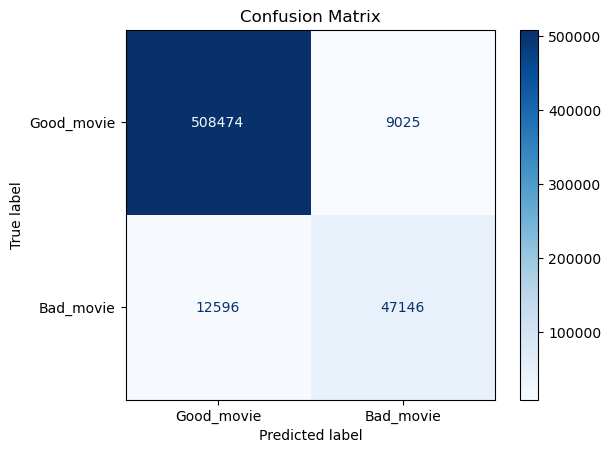

In [107]:

# Create the confusion matrix
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good_movie', 'Bad_movie'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()